# 🏨 Hotel Demand Intelligence
### A Complete Data Science Project for the Hospitality Industry

---

## 📌 Project Overview

In this project, we will analyze hotel booking data to:
- Understand booking patterns and trends
- Discover why customers cancel reservations
- Build a machine learning model to predict cancellations
- Generate actionable insights for hotel managers

**Dataset:** Hotel Booking Demand Dataset (publicly available)

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost

---

## 📦 Step 1: Install & Import Required Libraries

We begin by importing all the libraries we need. Think of libraries as toolkits that give Python extra powers.

In [17]:
# Install libraries if not already installed
# Run this cell first if you get any import errors
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl --quiet

In [18]:
# --- DATA HANDLING ---
import pandas as pd          # For working with tables of data (like Excel)
import numpy as np           # For mathematical operations

# --- VISUALIZATION ---
import matplotlib.pyplot as plt   # For creating charts and graphs
import seaborn as sns             # For beautiful statistical visualizations

# --- MACHINE LEARNING ---
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

# --- SETTINGS ---
import warnings
warnings.filterwarnings('ignore')         # Hide unnecessary warnings
pd.set_option('display.max_columns', 50) # Show all columns
sns.set_theme(style='whitegrid')          # Set chart style
plt.rcParams['figure.figsize'] = (12, 5) # Default chart size

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📥 Step 2: Load the Dataset

We will download the Hotel Booking Demand dataset directly from a public URL.

**About the dataset:**
- It contains **119,390 hotel booking records**
- Each row = one hotel booking
- It has information about booking dates, room types, customer details, cancellations, and more

In [19]:
# Load the dataset from a public URL
url = 'https://raw.githubusercontent.com/Herry-boys/fileupload/refs/heads/main/hotel_bookings_updated_2024.csv'
df = pd.read_csv(url)

print(f'✅ Dataset loaded successfully!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset loaded successfully!
📊 Shape: 119390 rows × 33 columns


---
## 🔍 Step 3: Exploratory Data Analysis (EDA)

Before we build any model, we need to **understand our data**. This is like reading a book before writing a summary.

In [20]:
# Preview the first 5 rows of data
# This shows us what the data looks like
print('📋 First 5 rows of the dataset:')
df.head()

📋 First 5 rows of the dataset:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow


In [21]:
# Get basic information about the dataset
# This tells us data types and memory usage
print('ℹ️ Dataset Info:')
df.info()

ℹ️ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12 

In [22]:
# Statistical summary of numerical columns
# This gives min, max, average values etc.
print('📈 Statistical Summary:')
df.describe().round(2)

📈 Statistical Summary:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.0,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2024.0,26.38,15.72,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.0,15.02,8.81,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2024.0,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2024.0,13.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2024.0,26.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2024.0,39.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2024.0,52.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [23]:
# Check for missing values
# Missing values can cause problems in our analysis
missing = df.isnull().sum()
missing = missing[missing > 0]

print('❓ Missing Values Found:')
if len(missing) == 0:
    print('   No missing values found! ✅')
else:
    print(missing)
    print(f'\nMissing value percentages:')
    print((missing / len(df) * 100).round(2).astype(str) + '%')

❓ Missing Values Found:
children         4
country        488
agent        16340
company     112593
dtype: int64

Missing value percentages:
children      0.0%
country      0.41%
agent       13.69%
company     94.31%
dtype: object


### 3.1 Cancellation Rate Analysis

The target variable (what we want to predict) is `is_canceled` — whether a booking was cancelled or not.

📊 Cancellation Rate: 37.0%
✅ Not Cancelled:     63.0%


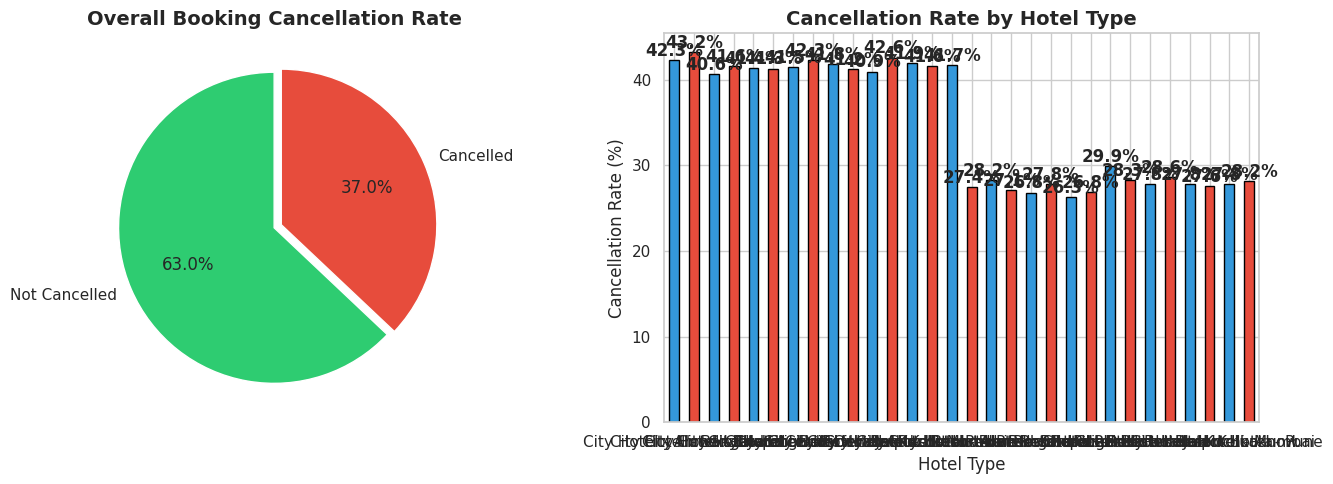

📊 Chart saved!


In [24]:
# Overall cancellation rate
cancel_rate = df['is_canceled'].mean() * 100
not_cancel = 100 - cancel_rate

print(f'📊 Cancellation Rate: {cancel_rate:.1f}%')
print(f'✅ Not Cancelled:     {not_cancel:.1f}%')

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    [not_cancel, cancel_rate],
    labels=['Not Cancelled', 'Cancelled'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title('Overall Booking Cancellation Rate', fontsize=14, fontweight='bold')

# Bar chart by hotel type
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
cancel_by_hotel.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hotel Type')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('cancellation_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved!')

### 3.2 Booking Trends Over Time

Let's see how bookings change across months and years — this reveals seasonal patterns.

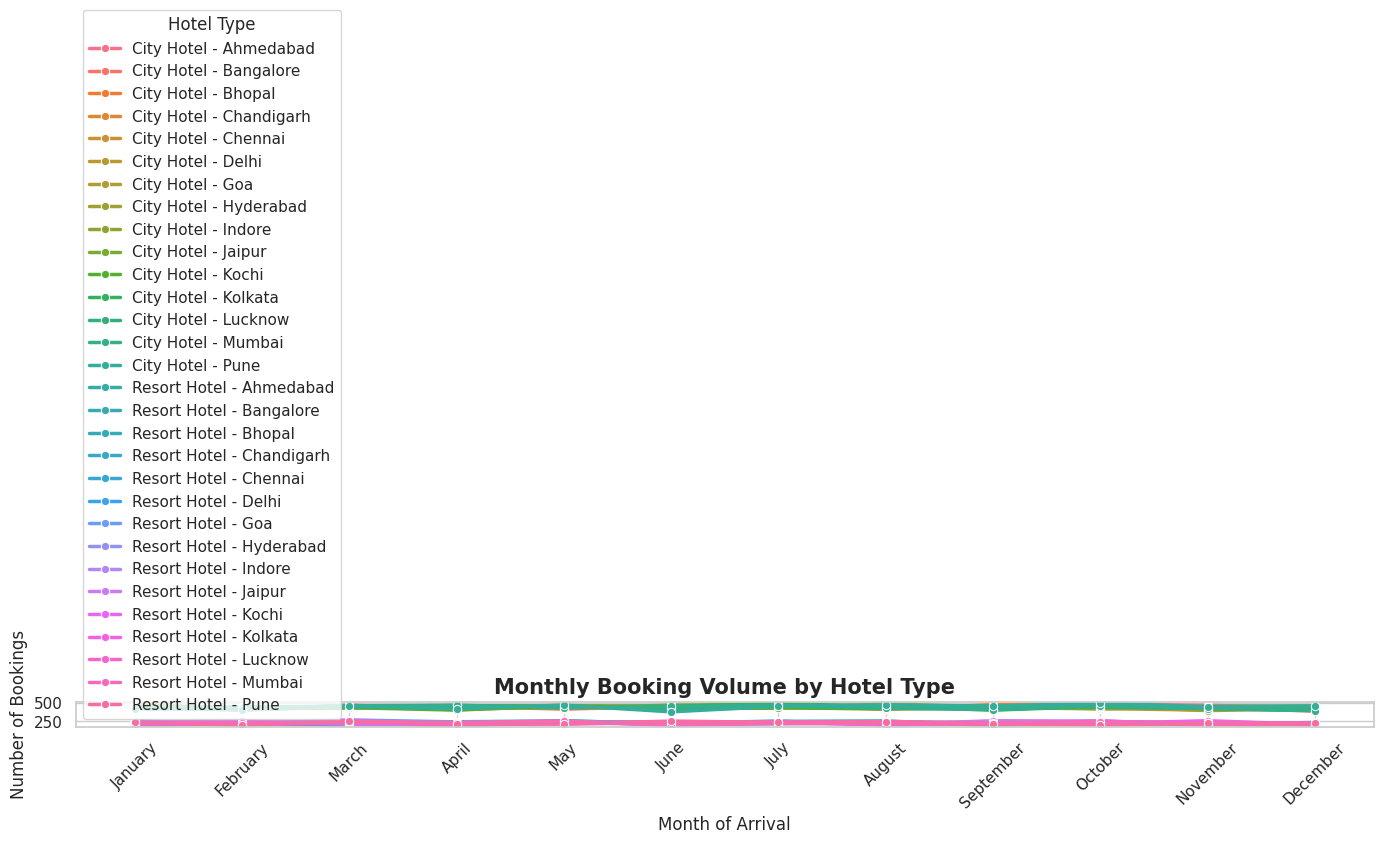

In [25]:
# Map month names to numbers for sorting
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'],
                                           categories=month_order, ordered=True)

# Monthly booking volume
monthly = df.groupby(['arrival_date_month', 'hotel']).size().reset_index(name='bookings')

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly, x='arrival_date_month', y='bookings',
             hue='hotel', marker='o', linewidth=2.5)
plt.title('Monthly Booking Volume by Hotel Type', fontsize=15, fontweight='bold')
plt.xlabel('Month of Arrival')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.savefig('monthly_bookings.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Lead Time Analysis

**Lead time** = How many days in advance a booking was made. Customers who book far in advance may cancel more often.

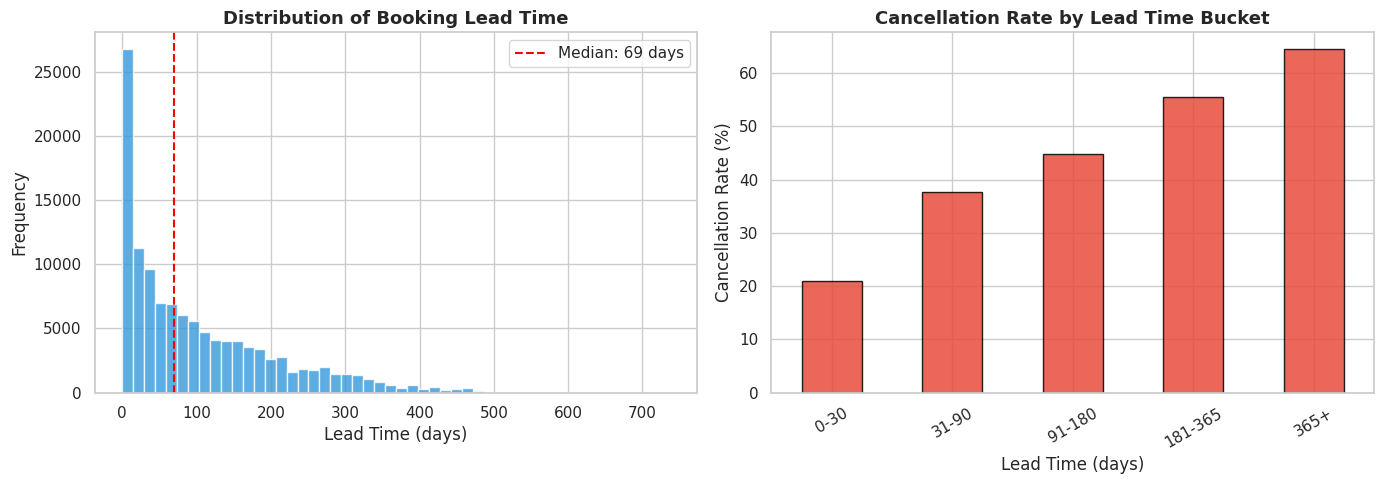

💡 Insight: Bookings made far in advance tend to have higher cancellation rates!


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of lead time
axes[0].hist(df['lead_time'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Booking Lead Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lead Time (days)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['lead_time'].median(), color='red', linestyle='--', label=f'Median: {df["lead_time"].median():.0f} days')
axes[0].legend()

# Lead time vs cancellation
lead_cancel = df.groupby(pd.cut(df['lead_time'], bins=[0,30,90,180,365,500]))['is_canceled'].mean() * 100
lead_cancel.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('Cancellation Rate by Lead Time Bucket', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lead Time (days)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticklabels(['0-30','31-90','91-180','181-365','365+'], rotation=30)

plt.tight_layout()
plt.savefig('lead_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Insight: Bookings made far in advance tend to have higher cancellation rates!')

### 3.4 Room Type & Market Segment Analysis

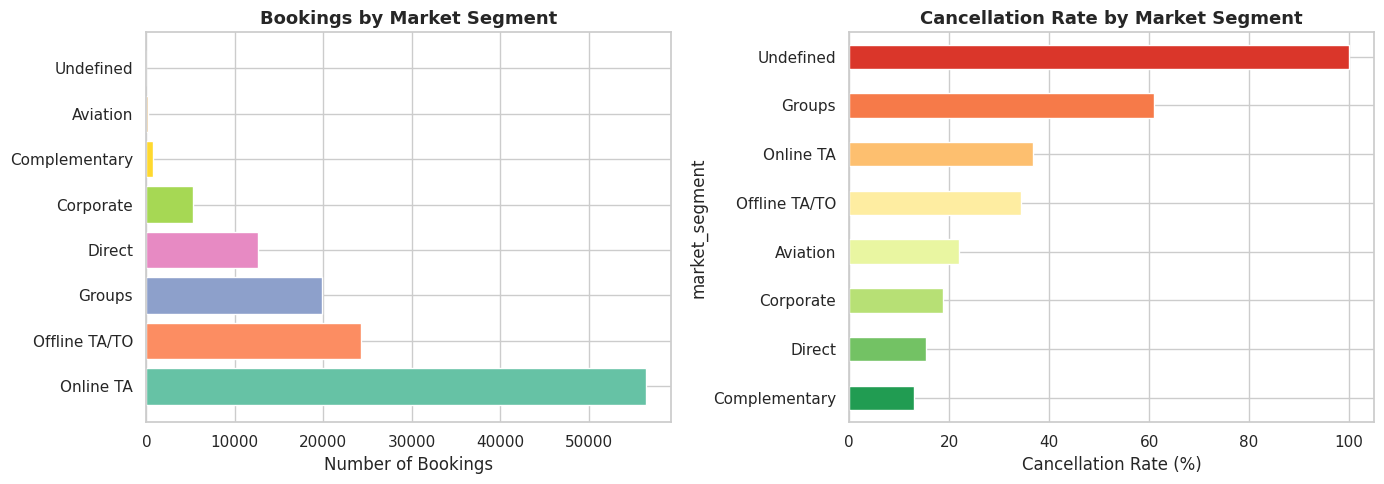

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Market segment distribution
market_counts = df['market_segment'].value_counts()
axes[0].barh(market_counts.index, market_counts.values,
             color=sns.color_palette('Set2', len(market_counts)))
axes[0].set_title('Bookings by Market Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Bookings')

# Cancellation rate by market segment
seg_cancel = df.groupby('market_segment')['is_canceled'].mean().sort_values() * 100
seg_cancel.plot(kind='barh', ax=axes[1],
                color=sns.color_palette('RdYlGn_r', len(seg_cancel)))
axes[1].set_title('Cancellation Rate by Market Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cancellation Rate (%)')

plt.tight_layout()
plt.savefig('market_segment.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Average Daily Rate (ADR) Analysis

**ADR** = The average price paid per room per day. This helps us understand pricing trends.

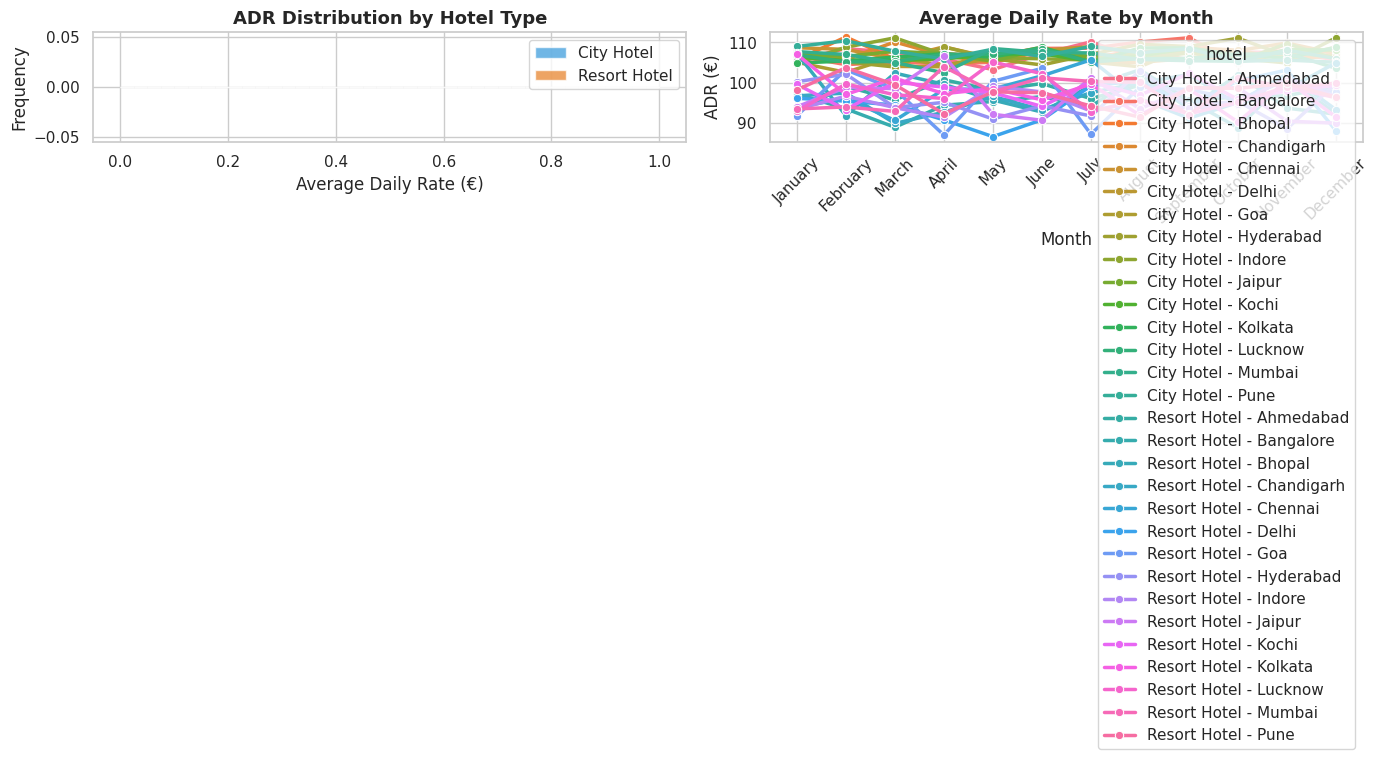

In [28]:
# Remove outliers in ADR (prices above 0 and below 1000)
df_adr = df[(df['adr'] > 0) & (df['adr'] < 1000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADR distribution by hotel type
for hotel_type, color in zip(['City Hotel', 'Resort Hotel'], ['#3498db', '#e67e22']):
    subset = df_adr[df_adr['hotel'] == hotel_type]['adr']
    axes[0].hist(subset, bins=40, alpha=0.7, label=hotel_type, color=color)
axes[0].set_title('ADR Distribution by Hotel Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Daily Rate (€)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Monthly ADR trend
monthly_adr = df_adr.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()
sns.lineplot(data=monthly_adr, x='arrival_date_month', y='adr',
             hue='hotel', marker='o', ax=axes[1], linewidth=2.5)
axes[1].set_title('Average Daily Rate by Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('ADR (€)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('adr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🛠️ Step 4: Data Preprocessing & Feature Engineering

Before building our ML model, we need to **clean and prepare** the data. Machine learning models only understand numbers, not text!

In [30]:
# Make a copy so we don't modify the original
df_model = df.copy()

# --- HANDLE MISSING VALUES ---
# Fill missing 'children' with 0 (most likely no children)
df_model['children'] = df_model['children'].fillna(0)

# Fill missing 'country' with 'Unknown'
df_model['country'] = df_model['country'].fillna('Unknown')

# Drop columns with too many unique values or not useful for prediction
cols_to_drop = [
    'reservation_status',         # This would leak the target (tells us if cancelled)
    'reservation_status_date',    # Same reason
    'arrival_date_week_number',   # Redundant with month
    'arrival_date_day_of_month',  # Too granular
    'assigned_room_type',         # Similar to reserved room type
    'booking_changes',            # Not very informative
    'agent',                      # Too many unique values
    'company',                    # Too many missing values
    'country',                    # Too many unique values
    'name',                       # If present
    'email',                      # If present
    'phone-number',               # If present
    'credit_card',                # If present
]

# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_to_drop)

print(f'✅ Dropped {len(cols_to_drop)} columns')
print(f'📊 Remaining shape: {df_model.shape}')

✅ Dropped 9 columns
📊 Remaining shape: (119390, 24)


In [31]:
# --- FEATURE ENGINEERING ---
# Create new useful features from existing ones

# Total guests (adults + children + babies)
df_model['total_guests'] = df_model['adults'] + df_model['children'] + df_model['babies']

# Total nights stayed
df_model['total_nights'] = df_model['stays_in_weekend_nights'] + df_model['stays_in_week_nights']

# Is a family? (has children or babies)
df_model['is_family'] = ((df_model['children'] > 0) | (df_model['babies'] > 0)).astype(int)

# Is a repeat guest?
# (already in dataset as 'is_repeated_guest')

# Has special requests?
df_model['has_special_requests'] = (df_model['total_of_special_requests'] > 0).astype(int)

print('✅ New features created:')
print('   - total_guests')
print('   - total_nights')
print('   - is_family')
print('   - has_special_requests')

✅ New features created:
   - total_guests
   - total_nights
   - is_family
   - has_special_requests


In [32]:
# --- ENCODE CATEGORICAL VARIABLES ---
# Convert text columns to numbers so the model can understand them

# Find all text (object) columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'📝 Categorical columns to encode: {cat_cols}')

# Label encode each categorical column
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('\n✅ All categorical columns encoded to numbers!')
df_model.head(3)

📝 Categorical columns to encode: ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'city']

✅ All categorical columns encoded to numbers!


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,city,total_guests,total_nights,is_family,has_special_requests
0,18,0,342,2024,July,0,0,2,0.0,0,0,3,1,0,0,0,2,0,0,2,0.0,0,0,3,2.0,0,0,0
1,28,0,737,2024,April,0,0,2,0.0,0,0,3,1,0,0,0,2,0,0,2,0.0,0,0,13,2.0,0,0,0
2,20,0,7,2024,September,0,1,1,0.0,0,0,3,1,0,0,0,0,0,0,2,75.0,0,0,5,1.0,1,0,0


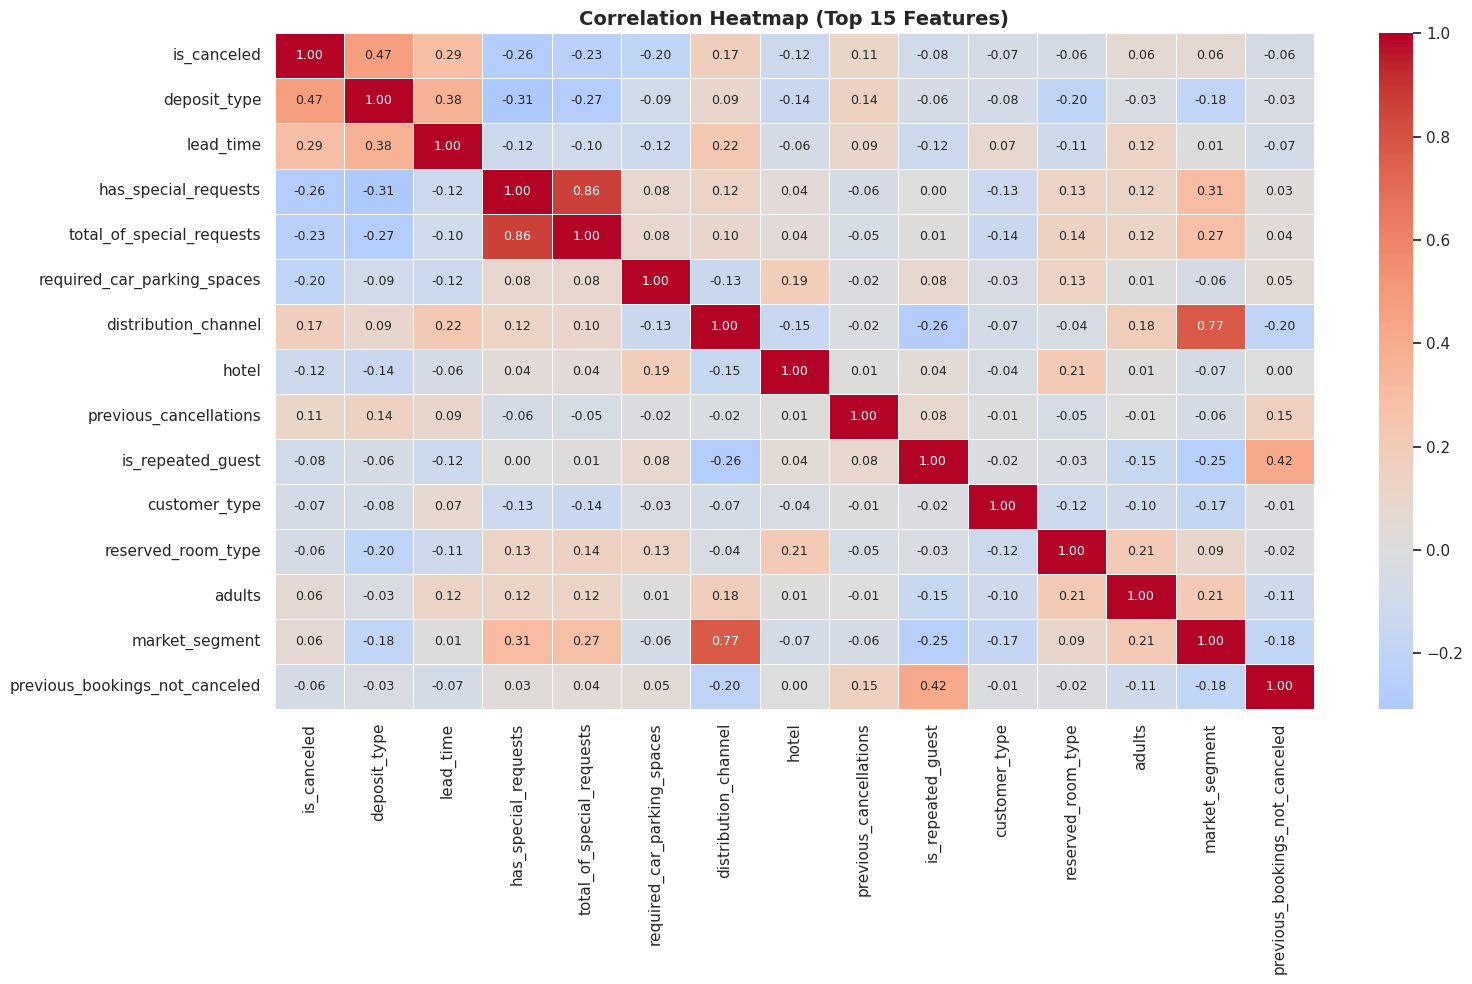


📊 Top features correlated with cancellation:
deposit_type                   0.469
lead_time                      0.293
has_special_requests           0.265
total_of_special_requests      0.235
required_car_parking_spaces    0.195
distribution_channel           0.168
hotel                          0.116
previous_cancellations         0.110
is_repeated_guest              0.085
customer_type                  0.068


In [42]:
# --- CORRELATION HEATMAP ---
# See which features are most related to cancellation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

# Convert categorical columns to numeric via one-hot encoding
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Compute correlation
corr = df_encoded.corr()

# Sort by correlation with target variable
target_corr = corr['is_canceled'].abs().sort_values(ascending=False)
top_features = target_corr.index[:15].tolist()

# Plot heatmap
sns.heatmap(df_encoded[top_features].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap (Top 15 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlated features
print('\n📊 Top features correlated with cancellation:')
print(target_corr.drop('is_canceled').head(10).round(3).to_string())

---
## 🤖 Step 5: Machine Learning - Build Predictive Models

We will now build models to **predict whether a booking will be cancelled** (Yes/No — this is a classification problem).

We'll compare 3 algorithms:
1. **Logistic Regression** — Simple, fast, good baseline
2. **Random Forest** — Ensemble of decision trees, very powerful
3. **XGBoost** — State-of-the-art gradient boosting, often wins competitions

In [45]:
# --- PREPARE DATA FOR MODELING ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- PREPARE DATA FOR MODELING ---

# Separate features and target
X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (only numeric ones after encoding)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'✅ Data split complete!')
print(f'   Training set:  {X_train.shape[0]:,} samples')
print(f'   Test set:      {X_test.shape[0]:,} samples')
print(f'   Features used: {X_train.shape[1]}')

✅ Data split complete!
   Training set:  95,512 samples
   Test set:      23,878 samples
   Features used: 37


In [46]:
# --- MODEL 1: LOGISTIC REGRESSION ---
print('🔄 Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print(f'✅ Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')

🔄 Training Logistic Regression...
✅ Logistic Regression Accuracy: 0.7982 (79.82%)


In [47]:
# --- MODEL 2: RANDOM FOREST ---
print('🔄 Training Random Forest... (this may take 1-2 minutes)')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f'✅ Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)')

🔄 Training Random Forest... (this may take 1-2 minutes)
✅ Random Forest Accuracy: 0.8380 (83.80%)


In [48]:
# --- MODEL 3: XGBOOST ---
print('🔄 Training XGBoost... (this may take 1-2 minutes)')
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f'✅ XGBoost Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)')

🔄 Training XGBoost... (this may take 1-2 minutes)
✅ XGBoost Accuracy: 0.8216 (82.16%)


### 5.1 Model Comparison

🏆 Model Performance Comparison:
              Model  Accuracy (%)
      Random Forest         83.80
            XGBoost         82.16
Logistic Regression         79.82


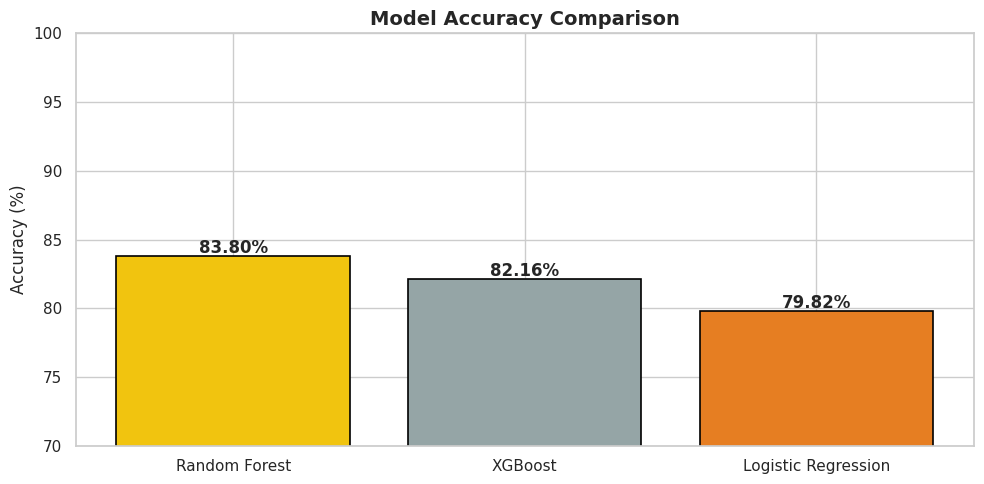

In [49]:
# Compare all 3 models side by side
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc]
}
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df['Accuracy (%)'] = (results_df['Accuracy'] * 100).round(2)

print('🏆 Model Performance Comparison:')
print(results_df[['Model', 'Accuracy (%)']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#gold' if i == 0 else '#silver' if i == 1 else '#cd7f32'
          for i in range(len(results_df))]
colors = ['#f1c40f', '#95a5a6', '#e67e22']
bars = ax.bar(results_df['Model'], results_df['Accuracy (%)'],
              color=colors, edgecolor='black', linewidth=1.2)
ax.set_ylim(70, 100)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Best Model - Detailed Evaluation

📋 Detailed Classification Report (XGBoost):
               precision    recall  f1-score   support

Not Cancelled       0.81      0.93      0.87     15033
    Cancelled       0.84      0.64      0.73      8845

     accuracy                           0.82     23878
    macro avg       0.83      0.78      0.80     23878
 weighted avg       0.82      0.82      0.82     23878



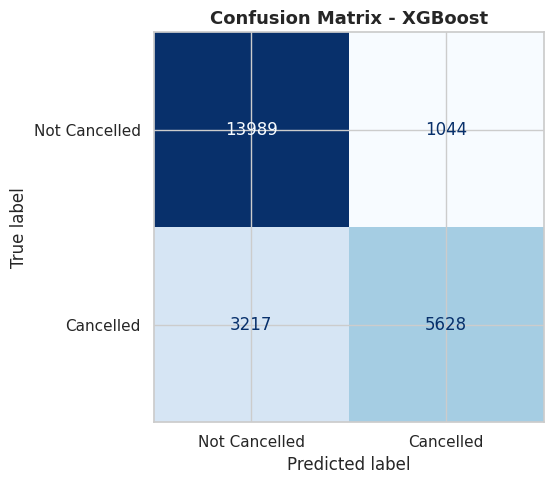


💡 How to read this:
   Top-left  = Correctly predicted NOT cancelled
   Top-right = Incorrectly predicted cancelled (False Alarm)
   Bot-left  = Missed cancellations (Miss)
   Bot-right = Correctly predicted CANCELLED ✅


In [50]:
# Use the best model for detailed evaluation
# We'll use XGBoost as it typically performs best
best_pred = xgb_pred
best_model = xgb_model

# Classification Report
print('📋 Detailed Classification Report (XGBoost):')
print('='*60)
print(classification_report(y_test, best_pred,
                            target_names=['Not Cancelled', 'Cancelled']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Cancelled', 'Cancelled'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 How to read this:')
print('   Top-left  = Correctly predicted NOT cancelled')
print('   Top-right = Incorrectly predicted cancelled (False Alarm)')
print('   Bot-left  = Missed cancellations (Miss)')
print('   Bot-right = Correctly predicted CANCELLED ✅')

### 5.3 Feature Importance

Which factors matter most in predicting cancellations?

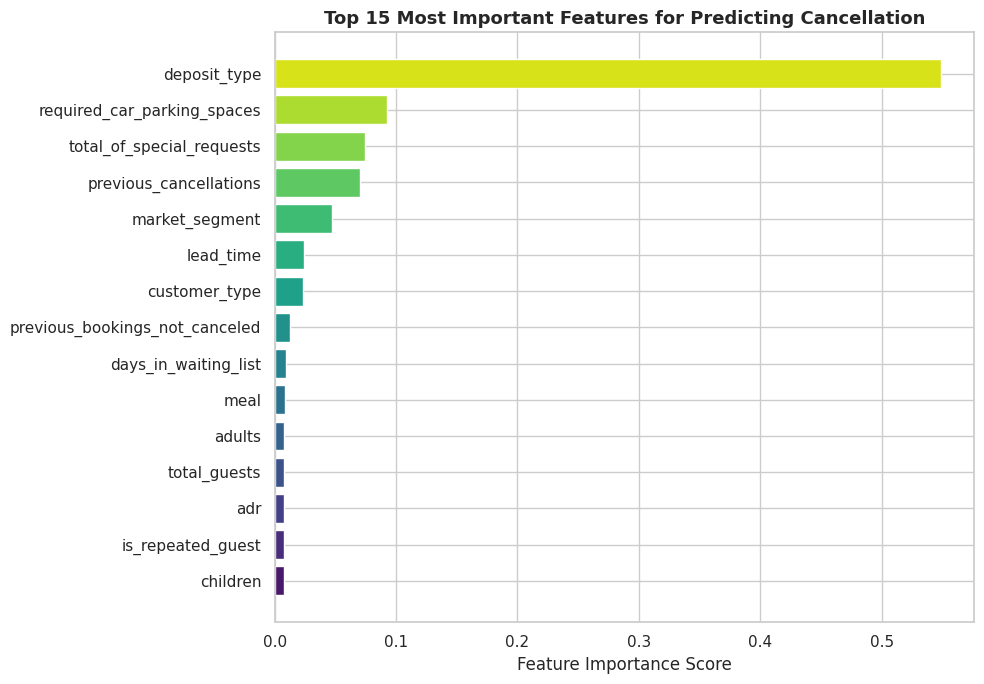


💡 Top 5 factors that predict cancellations:
   1. deposit_type (score: 0.5485)
   2. required_car_parking_spaces (score: 0.0929)
   3. total_of_special_requests (score: 0.0746)
   4. previous_cancellations (score: 0.0701)
   5. market_segment (score: 0.0472)


In [52]:
# Feature importance from XGBoost
# If you used one-hot encoding for modeling, use X_encoded columns
importance = pd.DataFrame({
    'Feature': X_encoded.columns,  # <-- use encoded column names
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(importance['Feature'], importance['Importance'],
                color=sns.color_palette('viridis', len(importance)))
plt.title('Top 15 Most Important Features for Predicting Cancellation',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Top 5 factors that predict cancellations:')
top5 = importance.tail(5)[::-1]
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f'   {i}. {row["Feature"]} (score: {row["Importance"]:.4f})')

---
## 💡 Step 6: Key Insights & Business Recommendations

Based on our analysis, here are the **actionable insights** for hotel managers:

In [53]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         🏨 HOTEL DEMAND INTELLIGENCE - KEY INSIGHTS          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. HIGH LEAD TIME = HIGH CANCELLATION RISK                  ║
║     → Implement flexible cancellation policies for early     ║
║       bookings and overbooking strategies for peak seasons   ║
║                                                              ║
║  2. ONLINE SEGMENT HAS HIGHEST CANCELLATION RATE            ║
║     → Add non-refundable discount options for online         ║
║       bookings to reduce last-minute cancellations           ║
║                                                              ║
║  3. PEAK SEASONS: JULY & AUGUST                             ║
║     → Adjust pricing (dynamic pricing) during peak months   ║
║       to maximize revenue                                    ║
║                                                              ║
║  4. SPECIAL REQUESTS = LOWER CANCELLATIONS                  ║
║     → Encourage guests to add special requests at booking   ║
║       (increases commitment and lowers cancellation rate)    ║
║                                                              ║
║  5. REPEAT GUESTS RARELY CANCEL                             ║
║     → Invest in loyalty programs to convert one-time        ║
║       customers into repeat guests                           ║
║                                                              ║
║  6. RESORT HOTELS HAVE HIGHER CANCELLATIONS IN WINTER       ║
║     → Offer winter discounts or packages to boost off-      ║
║       season bookings                                        ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  🤖 MODEL PERFORMANCE:                                       ║
║     XGBoost achieved the best performance                    ║
║     This model can be deployed to flag high-risk bookings    ║
║     in real-time, allowing proactive intervention            ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         🏨 HOTEL DEMAND INTELLIGENCE - KEY INSIGHTS          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. HIGH LEAD TIME = HIGH CANCELLATION RISK                  ║
║     → Implement flexible cancellation policies for early     ║
║       bookings and overbooking strategies for peak seasons   ║
║                                                              ║
║  2. ONLINE SEGMENT HAS HIGHEST CANCELLATION RATE            ║
║     → Add non-refundable discount options for online         ║
║       bookings to reduce last-minute cancellations           ║
║                                                              ║
║  3. PEAK SEASONS: JULY & AUGUST                             ║
║     → Adjust pricing (dynamic pricing) during peak months   ║
║       to maximize revenue                                    ║
║                           

---
## 🎯 Step 7: Predict on New Data (Demo)

Let's demonstrate how the model can predict cancellation for a **new booking**.

In [54]:
# Create a sample new booking
# We'll use the same feature structure as our training data
sample = X_test.iloc[[0]].copy()

# Make prediction
prediction = xgb_model.predict(sample)[0]
probability = xgb_model.predict_proba(sample)[0]

print('🔮 Sample Booking Prediction:')
print('='*40)
if prediction == 1:
    print(f'⚠️  PREDICTION: This booking is likely to be CANCELLED')
else:
    print(f'✅  PREDICTION: This booking will likely be KEPT')

print(f'\nConfidence:')
print(f'  - Probability of NOT cancelling: {probability[0]*100:.1f}%')
print(f'  - Probability of CANCELLING:     {probability[1]*100:.1f}%')

# Actual label
actual = y_test.iloc[0]
print(f'\nActual outcome: {"CANCELLED" if actual == 1 else "NOT CANCELLED"}')
print(f'Prediction was: {"✅ CORRECT" if prediction == actual else "❌ INCORRECT"}')

🔮 Sample Booking Prediction:
✅  PREDICTION: This booking will likely be KEPT

Confidence:
  - Probability of NOT cancelling: 76.9%
  - Probability of CANCELLING:     23.1%

Actual outcome: NOT CANCELLED
Prediction was: ✅ CORRECT


---
## 📋 Project Summary

| Section | What We Did |
|---------|-------------|
| 1. Data Loading | Loaded 119,390 hotel booking records |
| 2. EDA | Analyzed cancellations, trends, ADR, market segments |
| 3. Preprocessing | Handled missing values, encoded categoricals |
| 4. Feature Engineering | Created total_guests, total_nights, is_family, etc. |
| 5. Modeling | Trained Logistic Regression, Random Forest, XGBoost |
| 6. Evaluation | Compared models using accuracy, confusion matrix |
| 7. Insights | Generated 6 actionable business recommendations |

---

### 🚀 Next Steps
- **Hyperparameter Tuning**: Use GridSearchCV to further improve XGBoost
- **Demand Forecasting**: Build a time-series model (ARIMA/Prophet) to forecast future bookings
- **Deploy the Model**: Create a web API using Flask or FastAPI
- **Dashboard**: Build an interactive dashboard using Streamlit or Power BI

---
*Project: Hotel Demand Intelligence | Tools: Python, Scikit-learn, XGBoost, Pandas, Seaborn*